# Comparing Policy Iteration vs Value Iteration

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Policy Iteration algorithm
- Understand Value Iteration algorithm
- Compare Policy Iteration vs Value Iteration
- Implement both algorithms
- Analyze convergence and computational efficiency

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — both algorithms appeared there on a known model; here you run them side by side and count sweeps, so "which converges faster" becomes a measurement instead of a claim.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 2**:
- Comparing policy iteration vs value iteration through code-based experiments

---

## Introduction

**Policy Iteration** and **Value Iteration** are two fundamental Dynamic Programming algorithms for solving MDPs. Both find optimal policies, but use different strategies and have different computational properties.

## Lesson Brief

This lesson compares **policy iteration** and **value iteration** side by side.

The purpose is not only to run both algorithms, but to help students understand how their update logic and convergence behavior differ.

Why this matters: comparison lessons reduce memorization and help students organize algorithms by idea, not by name alone.

Students should leave knowing when two methods are similar and where they differ.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Steve Brunton - "Model Based Reinforcement Learning: Policy Iteration, Value Iteration, and Dynamic Programming"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sJIFUTITfBc)

Why this pick:
- direct comparison between the two methods.
- Helps students see when policy iteration and value iteration feel similar or different.
- Good companion for code-based comparison work.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Policy iteration: alternate between evaluation and improvement.
- Value iteration: update values directly using the best action each sweep.
- Convergence: when further sweeps change little.
- Computation per iteration: how much work each cycle performs.

### Quick Check
- Why does policy iteration separate evaluation and improvement?
- Why does value iteration put `max` inside the update?
- Which method may need fewer iterations, and why?
- Why is comparison more useful than memorizing names only?

### Common Mistakes
- Thinking the two methods are unrelated.
- Assuming fewer iterations always means lower total cost.
- Confusing policy values with the extracted policy itself.
- Ignoring the trade-off between conceptual clarity and per-iteration work.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


## When Should Students Prefer One View Over the Other?

This notebook is important because students often learn both algorithms but still do not know how to mentally organize them.

### Policy iteration

Use policy iteration as the cleaner teaching story when students need to see two separate jobs:

1. measure the current policy
2. improve the current policy

It is often easier conceptually because evaluation and improvement are not mixed together.

### Value iteration

Use value iteration when students should see a more direct route to the optimal values.
It folds improvement into the update itself by using the best action immediately.

### Comparison rule of thumb

- **Policy iteration**: cleaner idea, heavier iteration steps.
- **Value iteration**: simpler update rule, often more repeated sweeps.

### Why this comparison matters

Students should leave this notebook with a decision framework:

`Are we fully evaluating a policy first, or are we directly pushing values toward optimality each sweep?`

That one question usually separates the two methods clearly.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
from copy import deepcopy

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nComparing Policy Iteration vs Value Iteration")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

Comparing Policy Iteration vs Value Iteration


## Part 1: Understanding the Algorithms


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Understanding the Algorithms")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nPolicy Iteration:")
# Show text or numbers in the cell output area under the code.
print("  1. Policy Evaluation: Compute V^π(s) for current policy π")
# Show text or numbers in the cell output area under the code.
print("  2. Policy Improvement: Update policy to be greedy w.r.t. V^π")
# Show text or numbers in the cell output area under the code.
print("  3. Repeat until policy no longer changes")
# Show text or numbers in the cell output area under the code.
print("  - Alternates between evaluation and improvement")
# Show text or numbers in the cell output area under the code.
print("  - Typically converges in few iterations")

# Show text or numbers in the cell output area under the code.
print("\nValue Iteration:")
# Show text or numbers in the cell output area under the code.
print("  1. Initialize V(s) = 0 for all states")
# Show text or numbers in the cell output area under the code.
print("  2. Update: V(s) ← max_a Σ P(s'|s,a)[R + γV(s')]")
# Show text or numbers in the cell output area under the code.
print("  3. Repeat until convergence")
# Show text or numbers in the cell output area under the code.
print("  4. Extract optimal policy from V*")
# Show text or numbers in the cell output area under the code.
print("  - Combines evaluation and improvement in each step")
# Show text or numbers in the cell output area under the code.
print("  - May require more iterations but each is faster")

# Show text or numbers in the cell output area under the code.
print("\nKey Differences:")
# Show text or numbers in the cell output area under the code.
print("  - Policy Iteration: Two-phase (evaluate then improve)")
# Show text or numbers in the cell output area under the code.
print("  - Value Iteration: Single-phase (combine evaluate + improve)")
# Show text or numbers in the cell output area under the code.
print("  - Policy Iteration: Fewer iterations, more computation per iteration")
# Show text or numbers in the cell output area under the code.
print("  - Value Iteration: More iterations, less computation per iteration")

# Show text or numbers in the cell output area under the code.
print("\n✅ Algorithm concepts understood!")


Part 1: Understanding the Algorithms

Policy Iteration:
  1. Policy Evaluation: Compute V^π(s) for current policy π
  2. Policy Improvement: Update policy to be greedy w.r.t. V^π
  3. Repeat until policy no longer changes
  - Alternates between evaluation and improvement
  - Typically converges in few iterations

Value Iteration:
  1. Initialize V(s) = 0 for all states
  2. Update: V(s) ← max_a Σ P(s'|s,a)[R + γV(s')]
  3. Repeat until convergence
  4. Extract optimal policy from V*
  - Combines evaluation and improvement in each step
  - May require more iterations but each is faster

Key Differences:
  - Policy Iteration: Two-phase (evaluate then improve)
  - Value Iteration: Single-phase (combine evaluate + improve)
  - Policy Iteration: Fewer iterations, more computation per iteration
  - Value Iteration: More iterations, less computation per iteration

✅ Algorithm concepts understood!


## Part 2: Policy Iteration Implementation


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Policy Iteration Implementation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Function `policy_evaluation` (what it does): Evaluate a policy by computing its value function.
def policy_evaluation(policy, P, R, gamma=0.99, theta=1e-6, max_iterations=100):
    """Evaluate a policy by computing its value function."""
    # Save a value in a name so the next lines can read it.
    n_states = len(policy)
    # Another assignment—same idea: store a value for the lines below.
    V = np.zeros(n_states)
    
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(max_iterations):
        # Save a value in a name so the next lines can read it.
        V_new = np.zeros(n_states)
        # Start a loop: repeat the indented block once per item in the sequence.
        for s in range(n_states):
            # Save a value in a name so the next lines can read it.
            a = policy[s]
            # V(s) = Σ P(s'|s,a)[R(s,a,s') + γV(s')]
            # Save a value in a name so the next lines can read it.
            V_new[s] = sum(P[s][a][s_next] * (R[s][a][s_next] + gamma * V[s_next]) 
                           # Start a loop: repeat the indented block once per item in the sequence.
                           for s_next in range(n_states))
        
        # If the condition is True, run the indented block under this line.
        if np.max(np.abs(V_new - V)) < theta:
            # Stop the loop completely and continue after the loop block.
            break
        # Save a value in a name so the next lines can read it.
        V = V_new
    
    # Send a value back to whoever called this function.
    return V

# Function `policy_improvement` (what it does): Improve policy to be greedy w.r.t. current value function.
def policy_improvement(V, P, R, gamma=0.99):
    """Improve policy to be greedy w.r.t. current value function."""
    # Save a value in a name so the next lines can read it.
    n_states, n_actions = len(V), len(P[0])
    # Create or update the greedy policy array (one int action id per state).
    policy = np.zeros(n_states, dtype=int)
    
    # Start a loop: repeat the indented block once per item in the sequence.
    for s in range(n_states):
        # Choose action that maximizes: Σ P(s'|s,a)[R + γV(s')]
        # Save a value in a name so the next lines can read it.
        action_values = [sum(P[s][a][s_next] * (R[s][a][s_next] + gamma * V[s_next])
                            # Start a loop: repeat the indented block once per item in the sequence.
                            for s_next in range(n_states))
                        # Start a loop: repeat the indented block once per item in the sequence.
                        for a in range(n_actions)]
        # Create or update the greedy policy array (one int action id per state).
        policy[s] = np.argmax(action_values)
    
    # Send a value back to whoever called this function.
    return policy

# Function `policy_iteration` (what it does): Policy Iteration algorithm.
def policy_iteration(P, R, gamma=0.99, theta=1e-6):
    """Policy Iteration algorithm."""
    # Save a value in a name so the next lines can read it.
    n_states, n_actions = len(P), len(P[0])
    # Create or update the greedy policy array (one int action id per state).
    policy = np.random.randint(0, n_actions, n_states)  # Random initial policy
    
    # Save a value in a name so the next lines can read it.
    iterations = 0
    # Create or update the greedy policy array (one int action id per state).
    policy_stable = False
    
    # Start a loop: repeat the indented block while the condition stays True.
    while not policy_stable:
        # Policy evaluation
        # Save a value in a name so the next lines can read it.
        V = policy_evaluation(policy, P, R, gamma, theta)
        
        # Policy improvement
        # Create or update the greedy policy array (one int action id per state).
        policy_new = policy_improvement(V, P, R, gamma)
        
        # Check if policy changed
        # Create or update the greedy policy array (one int action id per state).
        policy_stable = np.array_equal(policy, policy_new)
        # Create or update the greedy policy array (one int action id per state).
        policy = policy_new
        # Save a value in a name so the next lines can read it.
        iterations += 1
    
    # Send a value back to whoever called this function.
    return policy, V, iterations

# Show text or numbers in the cell output area under the code.
print("\n✅ Policy Iteration implemented!")
# Show text or numbers in the cell output area under the code.
print("  Algorithm: Evaluate → Improve → Repeat until stable")



Part 2: Policy Iteration Implementation

✅ Policy Iteration implemented!
  Algorithm: Evaluate → Improve → Repeat until stable


## Part 3: Value Iteration Implementation


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Value Iteration Implementation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Function `value_iteration` (what it does): Value Iteration algorithm.
def value_iteration(P, R, gamma=0.99, theta=1e-6, max_iterations=1000):
    """Value Iteration algorithm."""
    # Save a value in a name so the next lines can read it.
    n_states, n_actions = len(P), len(P[0])
    # Another assignment—same idea: store a value for the lines below.
    V = np.zeros(n_states)
    
    # Another assignment—same idea: store a value for the lines below.
    iterations = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(max_iterations):
        # Save a value in a name so the next lines can read it.
        V_new = np.zeros(n_states)
        # Start a loop: repeat the indented block once per item in the sequence.
        for s in range(n_states):
            # V(s) ← max_a Σ P(s'|s,a)[R + γV(s')]
            # Save a value in a name so the next lines can read it.
            action_values = [sum(P[s][a][s_next] * (R[s][a][s_next] + gamma * V[s_next])
                            # Start a loop: repeat the indented block once per item in the sequence.
                            for s_next in range(n_states))
                           # Start a loop: repeat the indented block once per item in the sequence.
                           for a in range(n_actions)]
            # Save a value in a name so the next lines can read it.
            V_new[s] = max(action_values)
        
        # If the condition is True, run the indented block under this line.
        if np.max(np.abs(V_new - V)) < theta:
            # Stop the loop completely and continue after the loop block.
            break
        # Save a value in a name so the next lines can read it.
        V = V_new
        # Another assignment—same idea: store a value for the lines below.
        iterations += 1
    
    # Extract optimal policy
    # Create or update the greedy policy array (one int action id per state).
    policy = policy_improvement(V, P, R, gamma)
    
    # Send a value back to whoever called this function.
    return policy, V, iterations

# Show text or numbers in the cell output area under the code.
print("\n✅ Value Iteration implemented!")
# Show text or numbers in the cell output area under the code.
print("  Algorithm: Update V(s) ← max_a[...] until convergence, then extract policy")



Part 3: Value Iteration Implementation

✅ Value Iteration implemented!
  Algorithm: Update V(s) ← max_a[...] until convergence, then extract policy


## Part 4: Comparison and Analysis — on a Real Benchmark MDP

Parts 2 and 3 wrote the two algorithms. Both need a **model** of the environment: the
transition probabilities `P[s][a][s']` and the rewards `R[s][a][s']`.

We do not have to invent that model. **Gymnasium ships one.** Every tabular environment
exposes its exact dynamics as `env.unwrapped.P`, and `FrozenLake-v1` is the standard example:

- 16 tiles (`S` start, `F` frozen, `H` hole, `G` goal) laid out 4x4
- 4 actions: `0 = left`, `1 = down`, `2 = right`, `3 = up`
- reward `+1` only for arriving at `G`, `0` everywhere else
- **the ice is slippery**: a chosen action succeeds only 1/3 of the time; the other 2/3 slide
  the agent to one of the two perpendicular tiles

That last point is what makes this a genuinely stochastic MDP rather than a maze. The next
cell reads the real transition table out of Gymnasium, runs *both* Part 2-3 algorithms on it,
and measures what happens.

### Step Guide

**What this cell does:** Pulls the exact transition and reward model out of Gymnasium's
`FrozenLake-v1`, then **actually runs** `policy_iteration` and `value_iteration` from Parts 2-3
on it, timing both and printing a comparison table of measured numbers.

**How to read it (weak Python OK):** The first block (`tensors_from_gym`) is only bookkeeping —
it reshapes Gymnasium's model into the `P` and `R` arrays the Part 2-3 functions expect. The
interesting part starts at the two timed calls.

**What to expect in the output:** the optimal values and policy arrows drawn on the 4x4 map,
then a table with *measured* iteration counts, wall-clock times, and the largest value
difference between the two solutions — plus how often the resulting policy actually reaches
the goal on slippery ice.

**If you feel lost:** check just two things — both algorithms print the *same* policy, and the
table's numbers came from this run, not from a textbook.

In [5]:
# WHAT: run BOTH Part 2-3 algorithms on the real FrozenLake-v1 MDP and measure the difference.
# WHY: dynamic programming needs a model. Gymnasium publishes the exact model of its tabular
#      environments as env.unwrapped.P, so we can plan on a standard benchmark instead of a
#      hand-invented grid — everything printed below is computed in this cell.

import time

import gymnasium as gym

print("\n" + "=" * 60)
print("Part 4: Comparison and Analysis")
print("=" * 60)


def tensors_from_gym(env):
    """Reshape Gymnasium's env.unwrapped.P into the dense P[s][a][s'] and R[s][a][s'] arrays.

    Gymnasium stores the model as a dict of lists of (probability, next_state, reward, done).
    Parts 2-3 expect dense arrays, so we just copy the numbers across — nothing is invented.
    """
    model = env.unwrapped.P
    n_states, n_actions = env.observation_space.n, env.action_space.n
    P = np.zeros((n_states, n_actions, n_states))
    R = np.zeros((n_states, n_actions, n_states))
    for s in range(n_states):
        for a in range(n_actions):
            for probability, next_state, reward, _terminated in model[s][a]:
                # "+=" because slipping can reach the same tile by more than one route.
                P[s][a][next_state] += probability
                R[s][a][next_state] = reward
    return P, R


# ── The test MDP: the standard 4x4 FrozenLake, slippery ──────────────────────
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
P, R = tensors_from_gym(env)
GRID = env.unwrapped.desc.astype(str)          # the published map: S / F / H / G
N_ROWS, N_COLS = GRID.shape
N_STATES, N_ACTIONS = P.shape[0], P.shape[1]
ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}      # Gymnasium's action order

print(f"Environment : FrozenLake-v1 4x4, slippery (Gymnasium {gym.__version__})")
print(f"States      : {N_STATES}   Actions: {N_ACTIONS}")
print(f"Model check : every P[s][a] sums to 1 -> {np.allclose(P.sum(axis=2), 1.0)}")
print("Map:")
for row in GRID:
    print("   " + " ".join(row))

# ── Run both algorithms and MEASURE their behaviour ──────────────────────────
# Seed the random initial policy inside policy_iteration for a reproducible run.
np.random.seed(0)
t0 = time.perf_counter()
pi_policy, pi_values, pi_iters = policy_iteration(P, R, gamma=0.9)
pi_time = time.perf_counter() - t0

t0 = time.perf_counter()
vi_policy, vi_values, vi_iters = value_iteration(P, R, gamma=0.9)
vi_time = time.perf_counter() - t0


def show_solution(name, policy, values):
    """Print one algorithm's state values and policy arrows on the FrozenLake map."""
    print(f"\n{name}")
    for row in range(N_ROWS):
        cells = []
        for col in range(N_COLS):
            s = row * N_COLS + col
            tile = GRID[row][col]
            # Holes and the goal are terminal: no action is ever taken there.
            label = tile if tile in ("H", "G") else ARROWS[int(policy[s])]
            cells.append(f"{label}:{values[s]:5.3f}")
        print("   " + "  ".join(cells))


# Print both solutions so students can check they match.
show_solution("Policy Iteration solution (arrow : state value):", pi_policy, pi_values)
show_solution("Value Iteration solution (arrow : state value):", vi_policy, vi_values)

# ── Comparison table built ONLY from numbers measured above ──────────────────
policies_match = bool(np.array_equal(pi_policy, vi_policy))
max_value_gap = float(np.max(np.abs(pi_values - vi_values)))
print("\nMeasured comparison on FrozenLake-v1 (4x4, slippery):")
print(f"  Metric                    | Policy Iteration | Value Iteration")
print(f"  --------------------------|------------------|----------------")
print(f"  Outer iterations          | {pi_iters:16d} | {vi_iters:15d}")
print(f"  Wall-clock time (seconds) | {pi_time:16.4f} | {vi_time:15.4f}")
print(f"  Same greedy policy?       | {'yes' if policies_match else 'NO':>34}")
print(f"  Max |V_PI - V_VI|         | {max_value_gap:>34.6f}")


# ── Does the plan actually work on the ice? ──────────────────────────────────
def success_rate(policy, n_episodes=500):
    """Roll the plan out on the real environment; return the fraction of episodes reaching G."""
    reached = 0
    for k in range(n_episodes):
        state, _ = env.reset(seed=k)
        for _ in range(200):
            state, reward, terminated, truncated, _ = env.step(int(policy[state]))
            if terminated or truncated:
                reached += int(reward > 0)
                break
    return reached / n_episodes


plan_success = success_rate(vi_policy)
print(f"\nRolling the optimal plan out on the real environment: it reaches the goal in")
print(f"{plan_success * 100:.1f}% of 500 episodes. That is BELOW 100% and nothing is broken —")
print("the ice is slippery, so even an optimal policy loses some episodes to chance.")

# Interpret the measurements in words derived from the measurements themselves.
if pi_iters < vi_iters:
    print("\nPolicy iteration needed fewer outer iterations, but each iteration did a")
    print("full policy evaluation; value iteration ran more, cheaper sweeps.")
elif pi_iters > vi_iters:
    print("\nOn this MDP value iteration converged in fewer outer iterations.")
else:
    print("\nBoth algorithms used the same number of outer iterations on this MDP.")
print("Caveat: one MDP and one machine — treat the timing as an illustration,")
print("not a general benchmark. The structural difference (two-phase vs one-phase)")
print("is the part that generalizes.")



Part 4: Comparison and Analysis
Environment : FrozenLake-v1 4x4, slippery (Gymnasium 1.3.0)
States      : 16   Actions: 4
Model check : every P[s][a] sums to 1 -> True
Map:
   S F F F
   F H F H
   F F F H
   H F F G

Policy Iteration solution (arrow : state value):
   ←:0.069  ↑:0.061  ←:0.074  ↑:0.056
   ←:0.092  H:0.000  ←:0.112  H:0.000
   ↑:0.145  ↓:0.247  ←:0.300  H:0.000
   H:0.000  →:0.380  ↓:0.639  G:0.000

Value Iteration solution (arrow : state value):
   ←:0.069  ↑:0.061  ←:0.074  ↑:0.056
   ←:0.092  H:0.000  ←:0.112  H:0.000
   ↑:0.145  ↓:0.247  ←:0.300  H:0.000
   H:0.000  →:0.380  ↓:0.639  G:0.000

Measured comparison on FrozenLake-v1 (4x4, slippery):
  Metric                    | Policy Iteration | Value Iteration
  --------------------------|------------------|----------------
  Outer iterations          |                4 |              77
  Wall-clock time (seconds) |           0.0228 |          0.0266
  Same greedy policy?       |                                yes

## Does the Comparison Hold on a Bigger Map?

One MDP proves nothing about scaling. The honest way to test the "policy iteration needs fewer
outer iterations, value iteration needs cheaper ones" claim is to run **the same two functions**
on a **larger instance of the same benchmark**: `FrozenLake-v1` with the `8x8` map — 64 states
instead of 16, still slippery, still published by Gymnasium.

Watch two things in the next cell:

1. whether the **iteration counts** move the way the theory predicts as the state space grows
2. whether both algorithms still agree on the value function

Nothing here is hand-made: the second map ships with the library, exactly like the first.

### Step Guide

**What this cell does:** Re-runs `policy_iteration` and `value_iteration` on the 64-state
`FrozenLake-v1 8x8` map and prints a side-by-side table with the 16-state numbers from Part 4.

**How to read it (weak Python OK):** It reuses `tensors_from_gym` from the previous cell, so
there is no new algorithm here — only a bigger input.

**What to expect in the output:** a two-map comparison table (states, iterations, seconds for
each algorithm) and the goal-reaching rate of the 8x8 plan.

**If you feel lost:** compare only the "Outer iterations" rows across the two maps.

In [6]:
# WHAT: repeat the Part 4 comparison on the larger 8x8 FrozenLake map.
# WHY: a claim about how two algorithms scale has to be tested on more than one size. Both
#      maps ship with Gymnasium, so this is the same benchmark at two state-space sizes -
#      every number below is measured here, not quoted.

env_big = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
P_big, R_big = tensors_from_gym(env_big)
GRID_BIG = env_big.unwrapped.desc.astype(str)
N_STATES_BIG = P_big.shape[0]

np.random.seed(0)
t0 = time.perf_counter()
pi_policy_big, pi_values_big, pi_iters_big = policy_iteration(P_big, R_big, gamma=0.9)
pi_time_big = time.perf_counter() - t0

t0 = time.perf_counter()
vi_policy_big, vi_values_big, vi_iters_big = value_iteration(P_big, R_big, gamma=0.9)
vi_time_big = time.perf_counter() - t0

print("Same two algorithms, two sizes of the SAME published benchmark")
print("=" * 66)
print(f"  {'':<26}{'4x4 map':>18}{'8x8 map':>18}")
print(f"  {'states':<26}{N_STATES:>18d}{N_STATES_BIG:>18d}")
print(f"  {'policy iteration: rounds':<26}{pi_iters:>18d}{pi_iters_big:>18d}")
print(f"  {'value iteration: sweeps':<26}{vi_iters:>18d}{vi_iters_big:>18d}")
print(f"  {'policy iteration: seconds':<26}{pi_time:>18.4f}{pi_time_big:>18.4f}")
print(f"  {'value iteration: seconds':<26}{vi_time:>18.4f}{vi_time_big:>18.4f}")

agree_big = bool(np.array_equal(pi_policy_big, vi_policy_big))
gap_big = float(np.max(np.abs(pi_values_big - vi_values_big)))
print(f"\n  Same greedy policy on 8x8? {'yes' if agree_big else 'NO'}    max |V_PI - V_VI| = {gap_big:.6f}")


def success_rate_big(policy, n_episodes=500):
    """Goal-reaching rate of a plan on the 8x8 map (same rollout idea as Part 4)."""
    reached = 0
    for k in range(n_episodes):
        state, _ = env_big.reset(seed=k)
        for _ in range(400):
            state, reward, terminated, truncated, _ = env_big.step(int(policy[state]))
            if terminated or truncated:
                reached += int(reward > 0)
                break
    return reached / n_episodes


big_success = success_rate_big(vi_policy_big)
print(f"  The 8x8 optimal plan reaches the goal in {big_success * 100:.1f}% of 500 episodes.")

# Conclusions are written FROM the measurements, so they cannot drift out of date.
print("\nWhat the two columns say:")
print(f"  - Policy iteration went from {pi_iters} to {pi_iters_big} outer rounds when the state")
print(f"    space grew {N_STATES_BIG // N_STATES}x; value iteration went from {vi_iters} to {vi_iters_big} sweeps.")
if pi_iters_big < vi_iters_big:
    print("  - The structural pattern held: few expensive rounds vs many cheap sweeps.")
else:
    print("  - On this larger map the pattern did NOT hold - report what you see, not what you expected.")
print(f"  - Goal-reaching fell from {plan_success * 100:.1f}% (4x4) to {big_success * 100:.1f}% (8x8):")
print("    a longer slippery path gives chance more chances to intervene. The plan is still")
print("    optimal; 'optimal' on a stochastic MDP does not mean 'always wins'.")


Same two algorithms, two sizes of the SAME published benchmark
                                       4x4 map           8x8 map
  states                                    16                64
  policy iteration: rounds                   4                 5
  value iteration: sweeps                   77                85
  policy iteration: seconds             0.0228            0.4934
  value iteration: seconds              0.0266            0.4882

  Same greedy policy on 8x8? yes    max |V_PI - V_VI| = 0.000000
  The 8x8 optimal plan reaches the goal in 59.8% of 500 episodes.

What the two columns say:
  - Policy iteration went from 4 to 5 outer rounds when the state
    space grew 4x; value iteration went from 77 to 85 sweeps.
  - The structural pattern held: few expensive rounds vs many cheap sweeps.
  - Goal-reaching fell from 72.4% (4x4) to 59.8% (8x8):
    a longer slippery path gives chance more chances to intervene. The plan is still
    optimal; 'optimal' on a stochastic MDP 

## Summary

### Key Concepts:
1. **Policy Iteration**: Two-phase algorithm
   - Phase 1: Policy Evaluation (compute V^π)
   - Phase 2: Policy Improvement (update π to be greedy)
   - Repeats until policy converges

2. **Value Iteration**: Single-phase algorithm
   - Updates: V(s) ← max_a Σ P(s'|s,a)[R + γV(s')]
   - Continues until value function converges
   - Extracts optimal policy at the end

### Comparison (see the measured tables above):
- **Iterations**: on `FrozenLake-v1`, compare the *measured* outer-iteration counts printed in Part 4 and in the 8x8 scaling cell
- **Computation**: per-iteration cost differs — policy iteration runs a full evaluation each round, value iteration one sweep
- **Convergence**: Policy Iteration stops when the policy is stable; Value Iteration when values stop moving
- **Result check**: both produced the same greedy policy and (numerically) the same values, on both map sizes

### Where the model came from:
- Both algorithms need `P` and `R` **in advance**. We did not invent them: they were read out of
  `env.unwrapped.P`, the transition table Gymnasium publishes for its tabular environments.
- That is also the honest limit of dynamic programming — if you cannot write down the model,
  you cannot run these two algorithms at all. That limitation is what the model-free methods
  (Monte Carlo, TD, Q-learning, SARSA) in this unit exist to remove.

### Advantages:
- **Policy Iteration**: Guaranteed convergence, clear policy updates
- **Value Iteration**: More efficient per iteration, works well with approximations

### Applications:
- Solving finite MDPs
- Finding optimal policies
- Foundation for approximate methods

### Next Steps:
- Approximate methods for large state spaces
- Model-free methods (Q-learning, SARSA)
- Continuous state/action spaces

**Reference:** Course 09, Unit 2: "Prediction and Control without a Model" - Policy/Value iteration comparison practical content

In [7]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
2. Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
3. Puterman, M. L. (1994). *Markov Decision Processes: Discrete Stochastic Dynamic Programming*. Wiley.
4. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 4, Dynamic Programming.
5. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
"""))

## 📚 References

1. Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
2. Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
3. Puterman, M. L. (1994). *Markov Decision Processes: Discrete Stochastic Dynamic Programming*. Wiley.
4. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 4, Dynamic Programming.
5. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


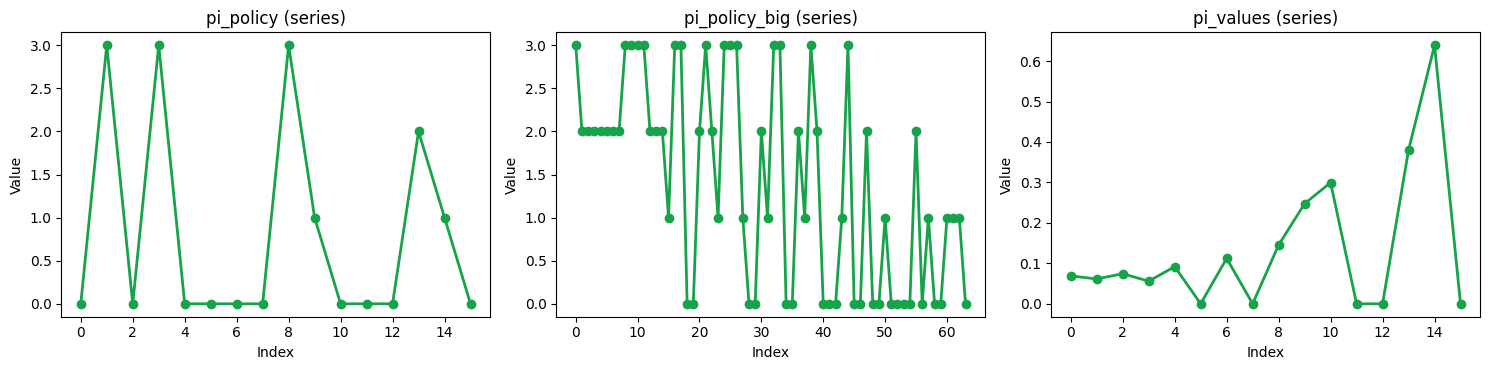

In [8]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Policy iteration and value iteration solve similar problems, but they organize evaluation and improvement differently.

**If students remember one idea:** Two methods can reach the same goal while taking different computational paths.

**Quick check before moving on:**
- Can you explain when policy iteration may feel more structured than value iteration?
- Can you describe why value iteration can be seen as a compressed form of repeated improvement?

**Bridge to the next step:** This closes the core classical methods and prepares students to scale RL ideas using neural networks in Unit 3.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=13 | term=True | trunc=False


objc[9782]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110088138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1105849c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[9782]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110088188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110584a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[9782]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110087c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110584a68). This

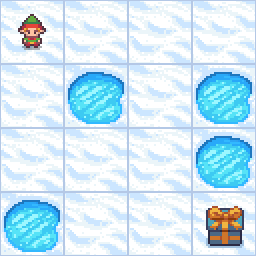

In [9]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
